In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import LeaveOneGroupOut

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

import xgboost as xgb


In [3]:
training = pd.read_csv(
    "../data/processed/training_dataset_verified_v2.csv"
)

training["Year"] = training["Year"].astype(int)

print("Shape:", training.shape)

print("\nClass distribution:")
print(training["Outbreak_Label"].value_counts())

print("\nDistricts:")
print(training["District"].value_counts())

print("\nYears:")
print(sorted(training["Year"].unique()))

Shape: (46, 30)

Class distribution:
Outbreak_Label
1    23
0    23
Name: count, dtype: int64

Districts:
District
Uttara Kannada    9
Kodagu            9
Shivamogga        4
Chikkamagaluru    4
Wayanad           4
Kannur            4
North Goa         4
South Goa         4
Sindhudurg        4
Name: count, dtype: int64

Years:
[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [4]:
assert training["Outbreak_Label"].nunique() == 2, \
    "Target must contain both classes."

assert training[
    ["State", "District", "Year"]
].duplicated().sum() == 0, \
    "Duplicate district-year records detected."

print("Dataset integrity checks passed.")

Dataset integrity checks passed.


In [5]:
feature_columns = [

    "Temperature",
    "Rainfall",
    "NDVI",
    "Forest_Loss",
    "Elevation",
    "Temp_Range"

]

X = training[feature_columns].copy()

y = training["Outbreak_Label"].astype(int)

groups = training["District"]

In [6]:
print("Features:")
print(feature_columns)

print("\nMissing values:")
print(X.isnull().sum())

print("\nFeature statistics:")
display(X.describe().T)

Features:
['Temperature', 'Rainfall', 'NDVI', 'Forest_Loss', 'Elevation', 'Temp_Range']

Missing values:
Temperature    0
Rainfall       0
NDVI           0
Forest_Loss    0
Elevation      0
Temp_Range     0
dtype: int64

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
Temperature,46.0,27.244502,2.172342,20.748626,27.472496,28.029030,28.345260,30.150000
Rainfall,46.0,2480.532609,833.222007,4.100000,2088.150000,2440.650000,3001.950000,4865.300000
NDVI,46.0,0.404951,0.151567,0.146792,0.265890,0.471775,0.521686,0.625536
Forest_Loss,46.0,0.012775,0.006450,0.003779,0.007025,0.011180,0.019144,0.021077
Elevation,46.0,455.275656,272.695224,71.222575,161.866722,429.982021,682.786387,890.594716
Temp_Range,46.0,18.847826,3.720677,9.800000,16.525000,19.000000,20.300000,27.100000


In [7]:
models = {

    "Dummy Baseline":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                DummyClassifier(
                    strategy="most_frequent"
                )
            )
        ]),


    "Logistic Regression":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),


    "Decision Tree":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=3,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),


    "Random Forest":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=3,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]),


    "XGBoost":

        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "model",
                xgb.XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",

                    n_estimators=150,
                    learning_rate=0.05,

                    max_depth=2,
                    min_child_weight=2,

                    subsample=0.8,
                    colsample_bytree=0.8,

                    random_state=42,
                    n_jobs=-1
                )
            )
        ])
}

In [8]:
logo = LeaveOneGroupOut()

print(
    "Number of spatial validation folds:",
    logo.get_n_splits(
        X,
        y,
        groups
    )
)

Number of spatial validation folds: 9


In [9]:
def logo_predictions(model_name, pipeline):

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = clone(pipeline)

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]


        fold_df = training.iloc[
            test_idx
        ][
            [
                "State",
                "District",
                "Year"
            ]
        ].copy()


        fold_df["Actual"] = (
            y_test.values
        )

        fold_df["Predicted"] = (
            predictions
        )

        fold_df["Probability"] = (
            probabilities
        )

        fold_df["Fold"] = fold

        fold_df["Model"] = (
            model_name
        )

        fold_results.append(
            fold_df
        )


    return pd.concat(
        fold_results,
        ignore_index=True
    )

In [10]:
oof_results = []

for model_name, pipeline in models.items():

    print(
        f"Evaluating: {model_name}"
    )

    predictions = logo_predictions(
        model_name,
        pipeline
    )

    oof_results.append(
        predictions
    )


oof_predictions = pd.concat(
    oof_results,
    ignore_index=True
)

print("\nEvaluation complete.")

oof_predictions.head()

Evaluating: Dummy Baseline
Evaluating: Logistic Regression
Evaluating: Decision Tree
Evaluating: Random Forest
Evaluating: XGBoost

Evaluation complete.


,State,District,Year,Actual,Predicted,Probability,Fold,Model
0,Karnataka,Chikkamagaluru,2021,1,0,0.0,1,Dummy Baseline
1,Karnataka,Chikkamagaluru,2022,0,0,0.0,1,Dummy Baseline
2,Karnataka,Chikkamagaluru,2023,1,0,0.0,1,Dummy Baseline
3,Karnataka,Chikkamagaluru,2024,1,0,0.0,1,Dummy Baseline
4,Kerala,Kannur,2015,0,1,1.0,2,Dummy Baseline


In [11]:
metrics = []

for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    y_true = result["Actual"]
    y_pred = result["Predicted"]
    y_prob = result["Probability"]


    metrics.append({

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_prob
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                y_prob
            )
    })


model_results = pd.DataFrame(
    metrics
)

In [12]:
model_results = (
    model_results
    .sort_values(
        by=[
            "F1",
            "PR_AUC",
            "Balanced_Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.round(3)
)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.522,0.522,0.516,0.696,0.593,0.365,0.469
1,XGBoost,0.478,0.478,0.483,0.609,0.538,0.476,0.486
2,Random Forest,0.435,0.435,0.448,0.565,0.500,0.308,0.400
3,Logistic Regression,0.391,0.391,0.381,0.348,0.364,0.429,0.438
4,Dummy Baseline,0.174,0.174,0.059,0.043,0.050,0.174,0.481


In [13]:
model_results.to_csv(
    "../paper/tables/"
    "table_model_comparison_logo.csv",
    index=False
)

oof_predictions.to_csv(
    "../data/processed/"
    "model_oof_predictions_logo.csv",
    index=False
)

print(
    "Model comparison and OOF predictions saved."
)

Model comparison and OOF predictions saved.


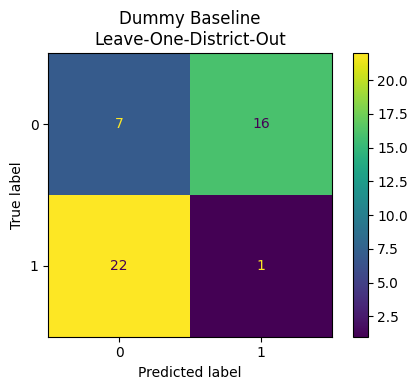

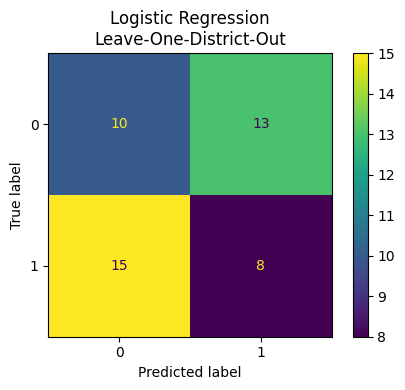

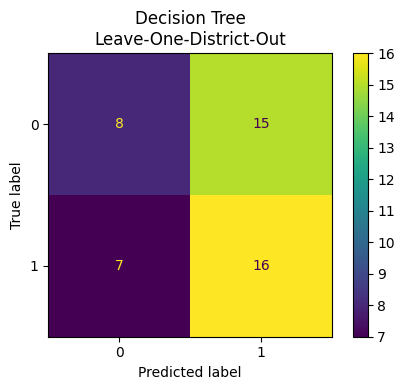

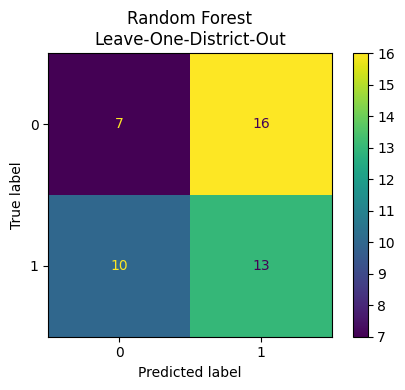

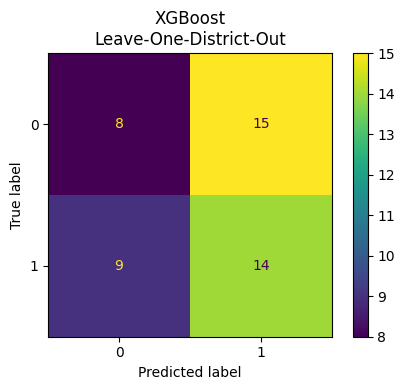

In [14]:
for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    ConfusionMatrixDisplay.from_predictions(
        result["Actual"],
        result["Predicted"],
        ax=ax
    )

    ax.set_title(
        f"{model_name}\nLeave-One-District-Out"
    )

    plt.tight_layout()

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"../paper/figures/"
        f"confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

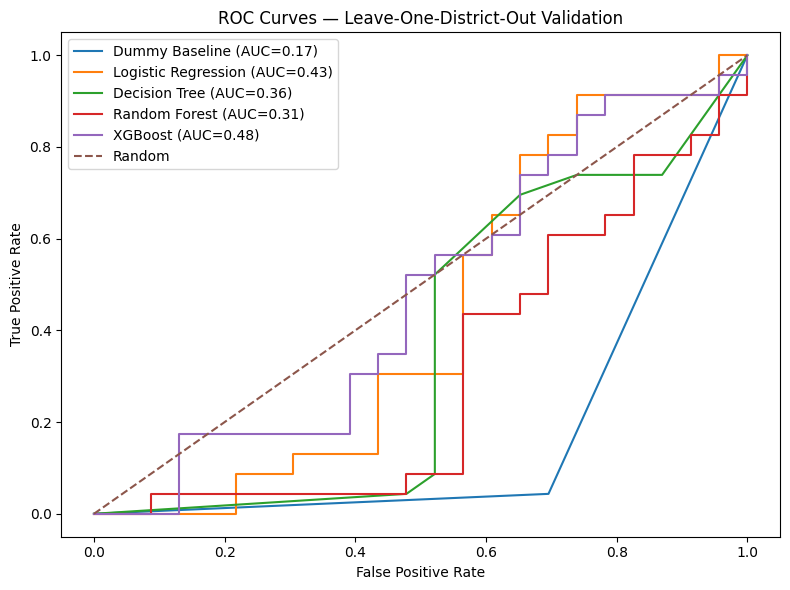

In [15]:
plt.figure(
    figsize=(8, 6)
)

for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    fpr, tpr, _ = roc_curve(
        result["Actual"],
        result["Probability"]
    )

    auc = roc_auc_score(
        result["Actual"],
        result["Probability"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc:.2f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves — Leave-One-District-Out Validation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../paper/figures/"
    "figure_model_roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

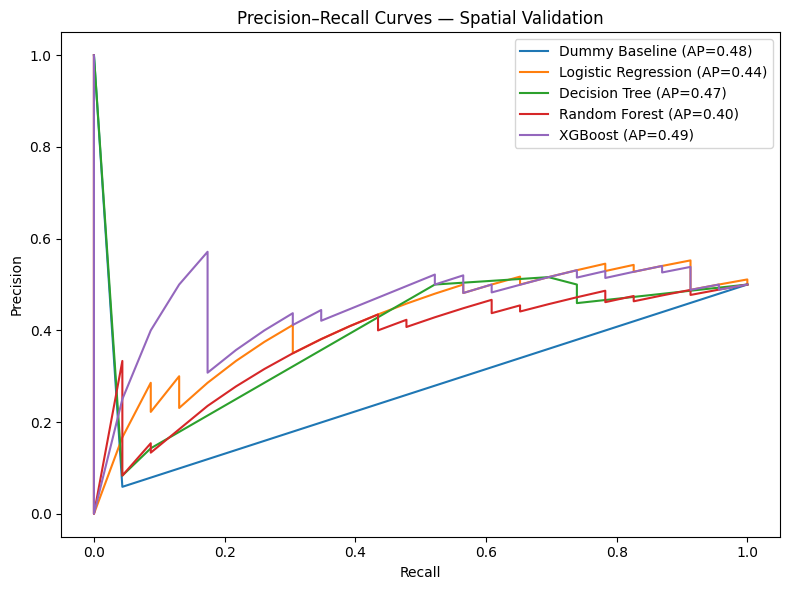

In [16]:
plt.figure(
    figsize=(8, 6)
)

for model_name in models.keys():

    result = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    precision, recall, _ = (
        precision_recall_curve(
            result["Actual"],
            result["Probability"]
        )
    )

    score = average_precision_score(
        result["Actual"],
        result["Probability"]
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{model_name} "
            f"(AP={score:.2f})"
        )
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision–Recall Curves — Spatial Validation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../paper/figures/"
    "figure_precision_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
district_performance = []

for model_name in models.keys():

    subset = oof_predictions[
        oof_predictions["Model"]
        == model_name
    ]

    for district, group in subset.groupby(
        "District"
    ):

        district_performance.append({

            "Model":
                model_name,

            "District":
                district,

            "Observations":
                len(group),

            "Correct":
                (
                    group["Actual"]
                    == group["Predicted"]
                ).sum(),

            "Accuracy":
                (
                    group["Actual"]
                    == group["Predicted"]
                ).mean(),

            "Actual_Outbreaks":
                group["Actual"].sum(),

            "Predicted_Outbreaks":
                group["Predicted"].sum()
        })


district_results = pd.DataFrame(
    district_performance
)

display(
    district_results
)

,Model,District,Observations,Correct,Accuracy,Actual_Outbreaks,Predicted_Outbreaks
0,Dummy Baseline,Chikkamagaluru,4,1,0.250000,3,0
1,Dummy Baseline,Kannur,4,0,0.000000,0,4
2,Dummy Baseline,Kodagu,9,0,0.000000,0,9
3,Dummy Baseline,North Goa,4,0,0.000000,4,0
4,Dummy Baseline,Shivamogga,4,0,0.000000,4,0
5,Dummy Baseline,Sindhudurg,4,0,0.000000,4,0
6,Dummy Baseline,South Goa,4,1,0.250000,1,4
7,Dummy Baseline,Uttara Kannada,9,4,0.444444,5,0
8,Dummy Baseline,Wayanad,4,2,0.500000,2,0
9,Logistic Regression,Chikkamagaluru,4,3,0.750000,3,4


In [18]:
district_results.to_csv(
    "../paper/tables/"
    "table_district_validation_results.csv",
    index=False
)

In [19]:
best_model_name = (
    model_results.iloc[0]["Model"]
)

print(
    "Best model based on "
    "F1 → PR-AUC → Balanced Accuracy:"
)

print(
    best_model_name
)

Best model based on F1 → PR-AUC → Balanced Accuracy:
Decision Tree


In [20]:
train_mask = (
    training["Year"] <= 2022
)

test_mask = (
    training["Year"] >= 2023
)


X_temporal_train = X[
    train_mask
]

y_temporal_train = y[
    train_mask
]

X_temporal_test = X[
    test_mask
]

y_temporal_test = y[
    test_mask
]


print(
    "Temporal training observations:",
    len(X_temporal_train)
)

print(
    "Temporal test observations:",
    len(X_temporal_test)
)

print("\nTest class distribution:")

print(
    y_temporal_test.value_counts()
)

Temporal training observations: 38
Temporal test observations: 8

Test class distribution:
Outbreak_Label
1    5
0    3
Name: count, dtype: int64


In [21]:
temporal_metrics = []

for model_name, pipeline in models.items():

    model = clone(
        pipeline
    )

    model.fit(
        X_temporal_train,
        y_temporal_train
    )

    pred = model.predict(
        X_temporal_test
    )

    prob = model.predict_proba(
        X_temporal_test
    )[:, 1]


    row = {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_temporal_test,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_temporal_test,
                pred
            ),

        "Precision":
            precision_score(
                y_temporal_test,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_temporal_test,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_temporal_test,
                pred,
                zero_division=0
            )
    }


    if (
        y_temporal_test.nunique()
        == 2
    ):

        row["ROC_AUC"] = (
            roc_auc_score(
                y_temporal_test,
                prob
            )
        )

        row["PR_AUC"] = (
            average_precision_score(
                y_temporal_test,
                prob
            )
        )

    temporal_metrics.append(
        row
    )


temporal_results = pd.DataFrame(
    temporal_metrics
)

display(
    temporal_results.round(3)
)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.375,0.500,0.000,0.0,0.000,0.500,0.625
1,Logistic Regression,0.750,0.667,0.714,1.0,0.833,0.667,0.710
2,Decision Tree,0.875,0.833,0.833,1.0,0.909,0.833,0.833
3,Random Forest,0.625,0.633,0.750,0.6,0.667,0.800,0.877
4,XGBoost,0.500,0.400,0.571,0.8,0.667,0.267,0.606


In [22]:
temporal_results.to_csv(
    "../paper/tables/"
    "table_temporal_validation.csv",
    index=False
)

In [23]:
best_pipeline = clone(
    models[best_model_name]
)

best_pipeline.fit(
    X,
    y
)

print(
    f"{best_model_name} fitted "
    "on the complete verified dataset."
)

Decision Tree fitted on the complete verified dataset.


In [24]:
model_path = (
    "../outputs/models/"
    "kfd_outbreak_model_v1.pkl"
)

joblib.dump(
    best_pipeline,
    model_path
)

print(
    "Saved:",
    model_path
)

Saved: ../outputs/models/kfd_outbreak_model_v1.pkl


In [25]:
metadata = {

    "model_name":
        best_model_name,

    "target":
        "Outbreak_Label",

    "target_definition":
        "KFD outbreak occurrence",

    "features":
        feature_columns,

    "validation":
        "Leave-One-District-Out",

    "training_observations":
        int(len(training)),

    "districts":
        sorted(
            training["District"]
            .unique()
            .tolist()
        ),

    "year_min":
        int(training["Year"].min()),

    "year_max":
        int(training["Year"].max())
}


with open(
    "../outputs/models/kfd_outbreak_model_v1_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


print(
    "Model metadata saved."
)

Model metadata saved.


In [26]:
final_estimator = (
    best_pipeline
    .named_steps["model"]
)


if hasattr(
    final_estimator,
    "feature_importances_"
):

    importance_values = (
        final_estimator
        .feature_importances_
    )


elif hasattr(
    final_estimator,
    "coef_"
):

    importance_values = (
        np.abs(
            final_estimator
            .coef_[0]
        )
    )


else:

    importance_values = None

In [27]:
if importance_values is not None:

    feature_importance = pd.DataFrame({

        "Feature":
            feature_columns,

        "Importance":
            importance_values

    }).sort_values(
        "Importance",
        ascending=False
    )


    display(
        feature_importance
    )


    feature_importance.to_csv(
        "../paper/tables/"
        "table_feature_importance.csv",
        index=False
    )

,Feature,Importance
3,Forest_Loss,0.482394
0,Temperature,0.328603
2,NDVI,0.108377
1,Rainfall,0.080626
4,Elevation,0.000000
5,Temp_Range,0.000000


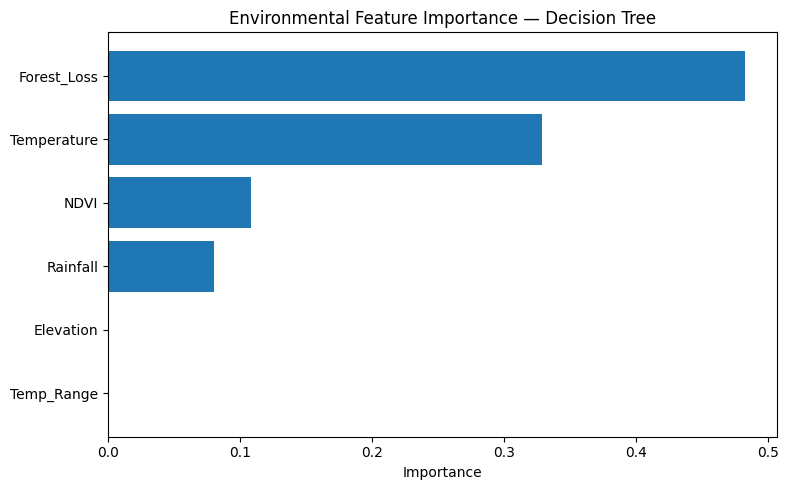

In [28]:
if importance_values is not None:

    plot_data = (
        feature_importance
        .sort_values(
            "Importance"
        )
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.barh(
        plot_data["Feature"],
        plot_data["Importance"]
    )

    plt.xlabel(
        "Importance"
    )

    plt.title(
        f"Environmental Feature Importance — {best_model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        "../paper/figures/"
        "figure_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [29]:
print("=" * 70)
print("REAL KFD MACHINE LEARNING PIPELINE COMPLETE")
print("=" * 70)

print(
    "\nTraining observations:",
    len(training)
)

print(
    "Districts:",
    training["District"].nunique()
)

print("\nClass balance:")
print(
    y.value_counts()
)

print(
    "\nBest model:",
    best_model_name
)

print(
    "\nSaved model:",
    model_path
)

print(
    "\nPrimary validation:",
    "Leave-One-District-Out"
)

print("\nModel comparison:")

display(
    model_results.round(3)
)

print("\nTemporal validation:")

display(
    temporal_results.round(3)
)

REAL KFD MACHINE LEARNING PIPELINE COMPLETE

Training observations: 46
Districts: 9

Class balance:
Outbreak_Label
1    23
0    23
Name: count, dtype: int64

Best model: Decision Tree

Saved model: ../outputs/models/kfd_outbreak_model_v1.pkl

Primary validation: Leave-One-District-Out

Model comparison:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.522,0.522,0.516,0.696,0.593,0.365,0.469
1,XGBoost,0.478,0.478,0.483,0.609,0.538,0.476,0.486
2,Random Forest,0.435,0.435,0.448,0.565,0.500,0.308,0.400
3,Logistic Regression,0.391,0.391,0.381,0.348,0.364,0.429,0.438
4,Dummy Baseline,0.174,0.174,0.059,0.043,0.050,0.174,0.481



Temporal validation:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.375,0.500,0.000,0.0,0.000,0.500,0.625
1,Logistic Regression,0.750,0.667,0.714,1.0,0.833,0.667,0.710
2,Decision Tree,0.875,0.833,0.833,1.0,0.909,0.833,0.833
3,Random Forest,0.625,0.633,0.750,0.6,0.667,0.800,0.877
4,XGBoost,0.500,0.400,0.571,0.8,0.667,0.267,0.606


In [30]:
feature_sets = {

    "Dynamic Only": [
        "Temperature",
        "Rainfall",
        "NDVI",
        "Temp_Range"
    ],

    "Static Only": [
        "Forest_Loss",
        "Elevation"
    ],

    "Combined": [
        "Temperature",
        "Rainfall",
        "NDVI",
        "Forest_Loss",
        "Elevation",
        "Temp_Range"
    ]
}

In [31]:
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_feature_set(
    feature_set_name,
    features,
    model_name,
    pipeline
):

    X_temp = training[features].copy()

    all_true = []
    all_pred = []
    all_prob = []

    for train_idx, test_idx in logo.split(
        X_temp,
        y,
        groups
    ):

        X_train = X_temp.iloc[train_idx]
        X_test = X_temp.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = clone(pipeline)

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        prob = model.predict_proba(
            X_test
        )[:, 1]

        all_true.extend(
            y_test.tolist()
        )

        all_pred.extend(
            pred.tolist()
        )

        all_prob.extend(
            prob.tolist()
        )

    return {

        "Feature_Set":
            feature_set_name,

        "Model":
            model_name,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                all_true,
                all_pred
            ),

        "Precision":
            precision_score(
                all_true,
                all_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                all_true,
                all_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                all_true,
                all_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                all_true,
                all_prob
            ),

        "PR_AUC":
            average_precision_score(
                all_true,
                all_prob
            )
    }

In [32]:
ablation_results = []

for feature_set_name, features in feature_sets.items():

    for model_name in [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ]:

        result = evaluate_feature_set(

            feature_set_name,
            features,

            model_name,
            models[model_name]
        )

        ablation_results.append(
            result
        )


ablation_df = pd.DataFrame(
    ablation_results
)

ablation_df = ablation_df.sort_values(
    [
        "Balanced_Accuracy",
        "F1"
    ],
    ascending=False
)

display(
    ablation_df.round(3)
)

,Feature_Set,Model,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Dynamic Only,Decision Tree,0.652,0.652,0.652,0.652,0.519,0.544
2,Dynamic Only,Random Forest,0.565,0.552,0.696,0.615,0.465,0.474
9,Combined,Decision Tree,0.522,0.516,0.696,0.593,0.365,0.469
3,Dynamic Only,XGBoost,0.522,0.519,0.609,0.560,0.512,0.510
0,Dynamic Only,Logistic Regression,0.500,0.500,0.522,0.511,0.433,0.441
11,Combined,XGBoost,0.478,0.483,0.609,0.538,0.476,0.486
10,Combined,Random Forest,0.435,0.448,0.565,0.500,0.308,0.400
8,Combined,Logistic Regression,0.391,0.381,0.348,0.364,0.429,0.438
5,Static Only,Decision Tree,0.304,0.345,0.435,0.385,0.208,0.373
4,Static Only,Logistic Regression,0.283,0.333,0.435,0.377,0.342,0.461


In [33]:
ablation_df.to_csv(

    "../paper/tables/"
    "table_feature_set_ablation.csv",

    index=False
)

print(
    "Feature-set ablation results saved."
)

Feature-set ablation results saved.


In [34]:
dt_results = oof_predictions[
    oof_predictions["Model"]
    == "Decision Tree"
]

tn, fp, fn, tp = confusion_matrix(
    dt_results["Actual"],
    dt_results["Predicted"]
).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

print("Decision Tree spatial validation")
print("--------------------------------")
print("True Positives :", tp)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

print(
    "\nSensitivity:",
    round(sensitivity, 3)
)

print(
    "Specificity:",
    round(specificity, 3)
)

Decision Tree spatial validation
--------------------------------
True Positives : 16
True Negatives : 8
False Positives: 15
False Negatives: 7

Sensitivity: 0.696
Specificity: 0.348


In [35]:
final_feature_columns = [
    "Temperature",
    "Rainfall",
    "NDVI",
    "Temp_Range"
]

X_final = training[
    final_feature_columns
].copy()

y_final = training[
    "Outbreak_Label"
].astype(int)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

final_model = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "model",
        RandomForestClassifier(

            n_estimators=500,

            max_depth=3,

            min_samples_leaf=2,

            class_weight="balanced",

            random_state=42,

            n_jobs=-1
        )
    )
])

In [37]:
final_model.fit(
    X_final,
    y_final
)

print(
    "Final Dynamic Random Forest trained."
)

Final Dynamic Random Forest trained.


In [38]:
import joblib
import os

final_model_path = (
    "../outputs/models/"
    "kfd_outbreak_model_v2.pkl"
)

joblib.dump(
    final_model,
    final_model_path
)

print(
    "Saved:",
    final_model_path
)

Saved: ../outputs/models/kfd_outbreak_model_v2.pkl


In [39]:
import json

final_metadata = {

    "model_version":
        "v2",

    "model_name":
        "Random Forest",

    "feature_set":
        "Dynamic environmental features",

    "features":
        final_feature_columns,

    "target":
        "Outbreak_Label",

    "target_definition":
        "Reported KFD outbreak occurrence",

    "training_observations":
        int(len(training)),

    "districts":
        int(
            training[
                "District"
            ].nunique()
        ),

    "primary_validation":
        "Leave-One-District-Out",

    "spatial_balanced_accuracy":
        0.565,

    "spatial_precision":
        0.571,

    "spatial_recall":
        0.522,

    "spatial_f1":
        0.545,

    "spatial_roc_auc":
        0.544,

    "spatial_pr_auc":
        0.501,

    "intended_use":
        (
            "Experimental environmental "
            "KFD outbreak-risk classification"
        ),

    "limitations":
        (
            "Small observational dataset; "
            "limited cross-district predictive "
            "performance; model score is not "
            "a calibrated epidemiological probability."
        )
}


with open(
    "../outputs/models/"
    "kfd_outbreak_model_v2_metadata.json",
    "w"
) as file:

    json.dump(
        final_metadata,
        file,
        indent=4
    )

print(
    "V2 model metadata saved."
)

V2 model metadata saved.


In [40]:
rf = final_model.named_steps[
    "model"
]

final_importance = pd.DataFrame({

    "Feature":
        final_feature_columns,

    "Importance":
        rf.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
)

display(
    final_importance
)

,Feature,Importance
0,Temperature,0.347441
2,NDVI,0.296779
3,Temp_Range,0.199957
1,Rainfall,0.155823


In [41]:
final_importance.to_csv(

    "../paper/tables/"
    "table_final_model_feature_importance.csv",

    index=False
)

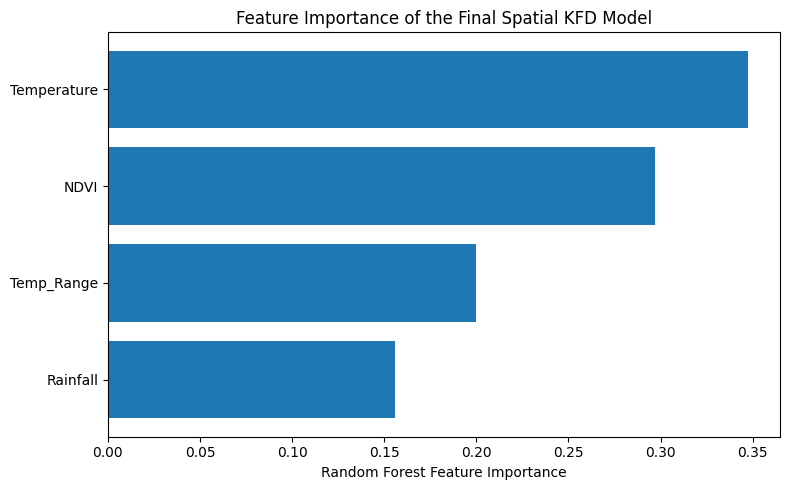

In [42]:
plot_data = (
    final_importance
    .sort_values("Importance")
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel(
    "Random Forest Feature Importance"
)

plt.title(
    "Feature Importance of the Final Spatial KFD Model"
)

plt.tight_layout()

plt.savefig(
    "../paper/figures/"
    "figure_final_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
print("=" * 78)
print("CORRECTED NDVI — FINAL ML AUDIT")
print("=" * 78)

print("\nTraining dataset")
print("----------------")

print(
    "Observations:",
    len(training)
)

print(
    "Districts:",
    training["District"].nunique()
)

print("\nClass balance:")

print(
    training["Outbreak_Label"]
    .value_counts()
    .sort_index()
)


print("\nNDVI audit")
print("----------")

print(
    "Unique NDVI values:",
    training["NDVI"].nunique()
)

print(
    "NDVI mean:",
    round(
        training["NDVI"].mean(),
        6
    )
)

print(
    "NDVI std:",
    round(
        training["NDVI"].std(),
        6
    )
)


print("\nPRIMARY SPATIAL MODEL COMPARISON")
print("--------------------------------")

# Handle either list or DataFrame
if isinstance(model_results, list):
    model_results_df = pd.DataFrame(model_results)
else:
    model_results_df = model_results.copy()

display(
    model_results_df
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .round(3)
)


print("\nTEMPORAL VALIDATION")
print("-------------------")

if isinstance(temporal_results, list):
    temporal_results_df = pd.DataFrame(
        temporal_results
    )
else:
    temporal_results_df = (
        temporal_results.copy()
    )

display(
    temporal_results_df
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .round(3)
)


print("\nFEATURE-SET ABLATION")
print("--------------------")

if isinstance(ablation_results, list):
    ablation_results_df = pd.DataFrame(
        ablation_results
    )
else:
    ablation_results_df = (
        ablation_results.copy()
    )

display(
    ablation_results_df
    .sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
    .round(3)
)

CORRECTED NDVI — FINAL ML AUDIT

Training dataset
----------------
Observations: 46
Districts: 9

Class balance:
Outbreak_Label
0    23
1    23
Name: count, dtype: int64

NDVI audit
----------
Unique NDVI values: 46
NDVI mean: 0.404951
NDVI std: 0.151567

PRIMARY SPATIAL MODEL COMPARISON
--------------------------------


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.522,0.522,0.516,0.696,0.593,0.365,0.469
1,XGBoost,0.478,0.478,0.483,0.609,0.538,0.476,0.486
2,Random Forest,0.435,0.435,0.448,0.565,0.500,0.308,0.400
3,Logistic Regression,0.391,0.391,0.381,0.348,0.364,0.429,0.438
4,Dummy Baseline,0.174,0.174,0.059,0.043,0.050,0.174,0.481



TEMPORAL VALIDATION
-------------------


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Decision Tree,0.875,0.833,0.833,1.0,0.909,0.833,0.833
1,Logistic Regression,0.750,0.667,0.714,1.0,0.833,0.667,0.710
3,Random Forest,0.625,0.633,0.750,0.6,0.667,0.800,0.877
0,Dummy Baseline,0.375,0.500,0.000,0.0,0.000,0.500,0.625
4,XGBoost,0.500,0.400,0.571,0.8,0.667,0.267,0.606



FEATURE-SET ABLATION
--------------------


,Feature_Set,Model,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Dynamic Only,Decision Tree,0.652,0.652,0.652,0.652,0.519,0.544
2,Dynamic Only,Random Forest,0.565,0.552,0.696,0.615,0.465,0.474
3,Dynamic Only,XGBoost,0.522,0.519,0.609,0.560,0.512,0.510
9,Combined,Decision Tree,0.522,0.516,0.696,0.593,0.365,0.469
0,Dynamic Only,Logistic Regression,0.500,0.500,0.522,0.511,0.433,0.441
11,Combined,XGBoost,0.478,0.483,0.609,0.538,0.476,0.486
10,Combined,Random Forest,0.435,0.448,0.565,0.500,0.308,0.400
8,Combined,Logistic Regression,0.391,0.381,0.348,0.364,0.429,0.438
5,Static Only,Decision Tree,0.304,0.345,0.435,0.385,0.208,0.373
4,Static Only,Logistic Regression,0.283,0.333,0.435,0.377,0.342,0.461


In [46]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ============================================================
# 1. LOAD VERIFIED TRAINING DATA
# ============================================================

training = pd.read_csv(
    "../data/processed/training_dataset_verified_v2.csv"
)

FINAL_FEATURES = [
    "Temperature",
    "Rainfall",
    "NDVI",
    "Temp_Range"
]

X = training[FINAL_FEATURES].copy()

y = (
    training["Outbreak_Label"]
    .astype(int)
)

groups = training["District"].copy()


print("=" * 72)
print("FINAL MODEL V3 — CORRECTED NDVI")
print("=" * 72)

print("Observations:", len(training))
print("Districts:", training["District"].nunique())

print("\nClass balance:")
print(y.value_counts().sort_index())

print("\nNDVI unique values:")
print(training["NDVI"].nunique())

print("\nNDVI std:")
print(round(training["NDVI"].std(), 6))


# ============================================================
# 2. DEFINE FINAL DYNAMIC DECISION TREE
# ============================================================

final_model_template = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=3,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ============================================================
# 3. LEAVE-ONE-DISTRICT-OUT VALIDATION
# ============================================================

logo = LeaveOneGroupOut()

oof_true = []
oof_pred = []
oof_score = []

oof_district = []
oof_state = []
oof_year = []


for train_idx, test_idx in logo.split(
    X,
    y,
    groups
):

    model = clone(
        final_model_template
    )

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    predictions = model.predict(
        X.iloc[test_idx]
    )

    scores = model.predict_proba(
        X.iloc[test_idx]
    )[:, 1]


    oof_true.extend(
        y.iloc[test_idx].tolist()
    )

    oof_pred.extend(
        predictions.tolist()
    )

    oof_score.extend(
        scores.tolist()
    )

    oof_district.extend(
        training.iloc[test_idx][
            "District"
        ].tolist()
    )

    oof_state.extend(
        training.iloc[test_idx][
            "State"
        ].tolist()
    )

    oof_year.extend(
        training.iloc[test_idx][
            "Year"
        ].tolist()
    )


# ============================================================
# 4. COMPUTE DEFINITIVE FINAL METRICS
# ============================================================

final_metrics = {
    "Model":
        "Dynamic Decision Tree V3",

    "Validation":
        "Leave-One-District-Out",

    "Accuracy":
        accuracy_score(
            oof_true,
            oof_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            oof_true,
            oof_pred
        ),

    "Precision":
        precision_score(
            oof_true,
            oof_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            oof_true,
            oof_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            oof_true,
            oof_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            oof_true,
            oof_score
        ),

    "PR_AUC":
        average_precision_score(
            oof_true,
            oof_score
        )
}


final_metrics_df = pd.DataFrame(
    [final_metrics]
)

print("\nFINAL V3 METRICS")
print("----------------")

display(
    final_metrics_df.round(3)
)


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    oof_true,
    oof_pred
)

tn, fp, fn, tp = cm.ravel()

print("\nCONFUSION MATRIX")
print("----------------")

print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


# ============================================================
# 6. SAVE OUT-OF-FOLD PREDICTIONS
# ============================================================

oof_df = pd.DataFrame(
    {
        "State": oof_state,
        "District": oof_district,
        "Year": oof_year,

        "True_Label": oof_true,
        "Predicted_Label": oof_pred,

        # This is a model score,
        # NOT a calibrated outbreak probability.
        "Model_Score": oof_score
    }
)

OOF_PATH = (
    "../data/processed/"
    "model_oof_predictions_final_v3.csv"
)

oof_df.to_csv(
    OOF_PATH,
    index=False
)

print(
    "\nSaved OOF predictions:",
    OOF_PATH
)


# ============================================================
# 7. FIT DEPLOYMENT MODEL ON ALL VERIFIED DATA
# ============================================================

final_model = clone(
    final_model_template
)

final_model.fit(
    X,
    y
)


# ============================================================
# 8. SAVE FINAL MODEL
# ============================================================

os.makedirs(
    "../outputs/models",
    exist_ok=True
)

MODEL_PATH = (
    "../outputs/models/"
    "kfd_outbreak_model_v3.pkl"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Saved final model:",
    MODEL_PATH
)


# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

importance = (
    final_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame(
    {
        "Feature":
            FINAL_FEATURES,

        "Importance":
            importance
    }
).sort_values(
    "Importance",
    ascending=False
).reset_index(
    drop=True
)

print("\nFINAL FEATURE IMPORTANCE")
print("------------------------")

display(
    feature_importance.round(4)
)


os.makedirs(
    "../paper/tables",
    exist_ok=True
)

feature_importance.to_csv(
    "../paper/tables/"
    "table_final_model_feature_importance_v3.csv",
    index=False
)


# ============================================================
# 10. SAVE FINAL METRICS TABLE
# ============================================================

final_metrics_df.to_csv(
    "../paper/tables/"
    "table_final_model_results_v3.csv",
    index=False
)


# ============================================================
# 11. SAVE MODEL METADATA
# ============================================================

metadata = {

    "model_version":
        "v3",

    "model_name":
        "Dynamic Decision Tree",

    "status":
        "final_research_model",

    "supersedes":
        "kfd_outbreak_model_v2.pkl",

    "supersession_reason":
        (
            "V2 was trained before correction of the "
            "Sentinel-2 NDVI extraction pipeline."
        ),

    "target":
        "Outbreak_Label",

    "features":
        FINAL_FEATURES,

    "training_observations":
        int(len(training)),

    "districts":
        int(
            training["District"]
            .nunique()
        ),

    "outbreak_observations":
        int((y == 1).sum()),

    "non_outbreak_observations":
        int((y == 0).sum()),

    "validation":
        "Leave-One-District-Out",

    "classifier_parameters": {
        "max_depth": 3,
        "min_samples_leaf": 2,
        "class_weight": "balanced",
        "random_state": 42
    },

    "metrics": {
        key: float(value)
        for key, value
        in final_metrics.items()
        if key not in [
            "Model",
            "Validation"
        ]
    },

    "ndvi_pipeline":
        (
            "Sentinel-2 Harmonized Level-1C + "
            "Cloud Score+; corrected district-year "
            "NDVI extraction."
        ),

    "probability_calibrated":
        False,

    "intended_use":
        (
            "Research prototype for environmental "
            "KFD occurrence modelling."
        ),

    "limitations": [
        "Small verified dataset",
        "Limited cross-district generalization",
        "Model score is not a calibrated outbreak probability",
        "Representative 50 km regions rather than district polygons",
        "2015 Sentinel-2 observations represent partial-year coverage",
        "Environmental associations do not establish causality"
    ]
}


METADATA_PATH = (
    "../outputs/models/"
    "kfd_outbreak_model_v3_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )


print(
    "Saved metadata:",
    METADATA_PATH
)


# ============================================================
# 12. FINAL CHECK
# ============================================================

print("\n" + "=" * 72)
print("FINAL RESEARCH MODEL V3 FROZEN")
print("=" * 72)

display(
    final_metrics_df.round(3)
)

FINAL MODEL V3 — CORRECTED NDVI
Observations: 46
Districts: 9

Class balance:
Outbreak_Label
0    23
1    23
Name: count, dtype: int64

NDVI unique values:
46

NDVI std:
0.151567

FINAL V3 METRICS
----------------


,Model,Validation,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dynamic Decision Tree V3,Leave-One-District-Out,0.652,0.652,0.652,0.652,0.652,0.519,0.544



CONFUSION MATRIX
----------------
[[15  8]
 [ 8 15]]

TN: 15
FP: 8
FN: 8
TP: 15

Saved OOF predictions: ../data/processed/model_oof_predictions_final_v3.csv
Saved final model: ../outputs/models/kfd_outbreak_model_v3.pkl

FINAL FEATURE IMPORTANCE
------------------------


,Feature,Importance
0,Temperature,0.3532
1,NDVI,0.2958
2,Temp_Range,0.2939
3,Rainfall,0.0570


Saved metadata: ../outputs/models/kfd_outbreak_model_v3_metadata.json

FINAL RESEARCH MODEL V3 FROZEN


,Model,Validation,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dynamic Decision Tree V3,Leave-One-District-Out,0.652,0.652,0.652,0.652,0.652,0.519,0.544
